In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/raw/spam.csv", encoding="latin-1")

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [4]:
df.shape

(5572, 5)

In [5]:
df = df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"])

df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
df.columns = ["target", "message"]

df.head()

,target,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
df.isnull().sum()

target     0
message    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(403)

In [9]:
df = df.drop_duplicates(keep="first")

df.shape

(5169, 2)

In [10]:
df["target"].value_counts()

target
ham     4516
spam     653
Name: count, dtype: int64

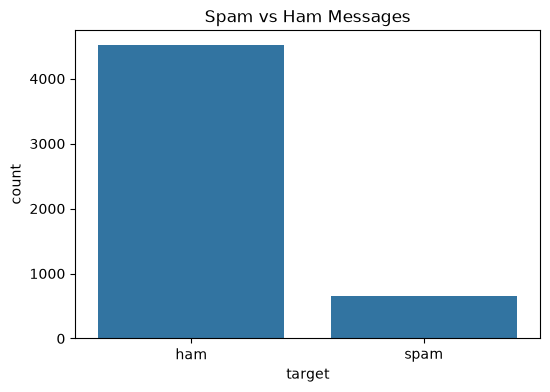

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x="target", data=df)

plt.title("Spam vs Ham Messages")
plt.show()

In [12]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["target"] = encoder.fit_transform(df["target"])

df.head()

,target,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [13]:
df["target"].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

In [14]:
df["num_characters"] = df["message"].apply(len)

df.head()

,target,message,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [15]:
df["num_words"] = df["message"].apply(lambda x: len(x.split()))

In [16]:
import sys

print(sys.executable)

c:\Users\akula\OneDrive\Desktop\DOCUMENTS\Seanergy_Preparation\Projects\Automated_Email_Classification\notebooks\venv\Scripts\python.exe


In [17]:
import os
print(os.getcwd())


c:\Users\akula\OneDrive\Desktop\DOCUMENTS\Seanergy_Preparation\Projects\Automated_Email_Classification\notebooks


In [18]:
import sys
print(sys.executable)
print(sys.path)

c:\Users\akula\OneDrive\Desktop\DOCUMENTS\Seanergy_Preparation\Projects\Automated_Email_Classification\notebooks\venv\Scripts\python.exe
['C:\\Users\\akula\\AppData\\Local\\Programs\\Python\\Python313\\python313.zip', 'C:\\Users\\akula\\AppData\\Local\\Programs\\Python\\Python313\\DLLs', 'C:\\Users\\akula\\AppData\\Local\\Programs\\Python\\Python313\\Lib', 'C:\\Users\\akula\\AppData\\Local\\Programs\\Python\\Python313', 'c:\\Users\\akula\\OneDrive\\Desktop\\DOCUMENTS\\Seanergy_Preparation\\Projects\\Automated_Email_Classification\\notebooks\\venv', '', 'c:\\Users\\akula\\OneDrive\\Desktop\\DOCUMENTS\\Seanergy_Preparation\\Projects\\Automated_Email_Classification\\notebooks\\venv\\Lib\\site-packages']


In [19]:
import importlib.util
spec = importlib.util.find_spec("regex")
print(spec)

ModuleSpec(name='regex', loader=<_frozen_importlib_external.SourceFileLoader object at 0x0000021B607CFB30>, origin='c:\\Users\\akula\\OneDrive\\Desktop\\DOCUMENTS\\Seanergy_Preparation\\Projects\\Automated_Email_Classification\\notebooks\\venv\\Lib\\site-packages\\regex\\__init__.py', submodule_search_locations=['c:\\Users\\akula\\OneDrive\\Desktop\\DOCUMENTS\\Seanergy_Preparation\\Projects\\Automated_Email_Classification\\notebooks\\venv\\Lib\\site-packages\\regex'])


In [20]:
df["num_sentences"] = df["message"].apply(lambda x: x.count(".") + x.count("!") + x.count("?"))


In [21]:
df["num_characters"] = df["message"].apply(len)

In [22]:
df["num_words"] = df["message"].apply(lambda x: len(x.split()))

In [23]:
df[["target", "num_characters", "num_words", "num_sentences"]].head()

,target,num_characters,num_words,num_sentences
0,0,111,20,8
1,0,29,6,6
2,1,155,28,1
3,0,49,11,6
4,0,61,13,0


In [24]:
df.groupby("target")[
    ["num_characters", "num_words", "num_sentences"]
].describe()

num_characters                                                    \
                count        mean        std   min    25%    50%    75%   
target                                                                    
0              4516.0   70.459256  56.358207   2.0   34.0   52.0   90.0   
1               653.0  137.891271  30.137753  13.0  132.0  149.0  157.0   

              num_words                                                      \
          max     count       mean        std  min   25%   50%   75%    max   
target                                                                        
0       910.0    4516.0  14.134632  11.116240  1.0   7.0  11.0  18.0  171.0   
1       224.0     653.0  23.681470   5.967672  2.0  22.0  25.0  28.0   35.0   

       num_sentences                                                
               count      mean       std  min  25%  50%  75%   max  
target                                                              
0             4516.0  2.384190  2.773408  0.0  1.0  2.0  3.0  42.0  
1              653.0  2.992343  1.902114  0.0  2.0  3.0  4.0  13.0

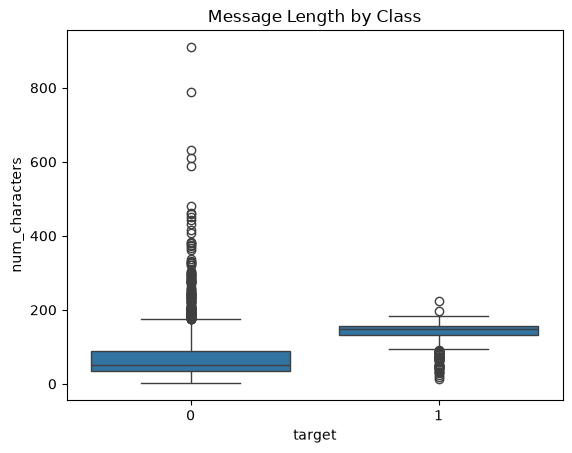

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="target", y="num_characters", data=df)
plt.title("Message Length by Class")
plt.show()
